<a href="https://colab.research.google.com/github/Ayon150/BDSET_EXAM/blob/main/job_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step-**7**

In [1]:
!python --version

Python 3.12.13


In [2]:
#import necessary python library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step-8**

In [4]:
from google.colab import files
import pandas as pd

print("Please select the dataset file from your local device:")
uploaded = files.upload()

Please select the dataset file from your local device:


Saving Job_1_resource_world_population (2).csv to Job_1_resource_world_population (2).csv


In [6]:
df=pd.read_csv('/content/Job_1_resource_world_population (2).csv')

**Step-9**

In [7]:
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [9]:
df.shape

(234, 17)

In [10]:
df.isnull().sum()

,0
Rank,0
CCA3,0
Country/Territory,0
Capital,0
Continent,0
2022 Population,0
2020 Population,0
2015 Population,0
2010 Population,0
2000 Population,0


**Step-10**

In [11]:
# Compute mean, median, variance, and standard deviation
# grouped by continent for 2022 Population
continent_stats = df.groupby("Continent")["2022 Population"].agg(
    Mean="mean",
    Median="median",
    Variance="var",
    Std_Dev="std"
).reset_index()

# Format numbers for better readability
continent_stats["Mean"]     = continent_stats["Mean"].map("{:,.0f}".format)
continent_stats["Median"]   = continent_stats["Median"].map("{:,.0f}".format)
continent_stats["Variance"] = continent_stats["Variance"].map("{:,.0f}".format)
continent_stats["Std_Dev"]  = continent_stats["Std_Dev"].map("{:,.0f}".format)

# Display the result
print(continent_stats.to_string(index=False))

    Continent       Mean     Median               Variance     Std_Dev
       Africa 25,030,367 13,352,864  1,411,677,713,816,725  37,572,300
         Asia 94,427,665 18,082,920 78,243,675,046,040,496 279,720,709
       Europe 14,862,951  5,228,714    743,375,725,622,748  27,264,917
North America 15,007,403    236,399  3,182,997,880,975,658  56,418,063
      Oceania  1,958,198    114,164     33,119,271,461,767   5,754,935
South America 31,201,186 15,112,555  3,105,366,454,936,978  55,725,815


**Step-11**

In [12]:

pop_cols = ['1970 Population', '1980 Population', '1990 Population',
            '2000 Population', '2010 Population', '2015 Population',
            '2020 Population', '2022 Population']


df_long = df.melt(
    id_vars=['Country/Territory', 'Continent'],
    value_vars=pop_cols,
    var_name='Year',
    value_name='Population'
)


df_long['Year'] = df_long['Year'].str.replace(' Population', '').astype(int)

#Sort by country and year
df_long = df_long.sort_values(['Country/Territory', 'Year'])

# Step 5 — Calculate cumulative population per country
df_long['Cumulative_Population'] = df_long.groupby(
    'Country/Territory')['Population'].cumsum()

# Display result
print(df_long[['Country/Territory', 'Year',
               'Population', 'Cumulative_Population']].to_string(index=False))

               Country/Territory  Year  Population  Cumulative_Population
                     Afghanistan  1970    10752971               10752971
                     Afghanistan  1980    12486631               23239602
                     Afghanistan  1990    10694796               33934398
                     Afghanistan  2000    19542982               53477380
                     Afghanistan  2010    28189672               81667052
                     Afghanistan  2015    33753499              115420551
                     Afghanistan  2020    38972230              154392781
                     Afghanistan  2022    41128771              195521552
                         Albania  1970     2324731                2324731
                         Albania  1980     2941651                5266382
                         Albania  1990     3295066                8561448
                         Albania  2000     3182021               11743469
                         Albania  2010

**Step-12**

In [13]:
print("=== BEFORE RENAMING ===")
print(df.columns.tolist())


new_columns = []

for col in df.columns:
    if "Population" in col:
        new_col = col.replace(" Population", "")
        new_columns.append(new_col)
    else:
        new_columns.append(col)

df.columns = new_columns

print()
print("=== AFTER RENAMING ===")
print(df.columns.tolist())

=== BEFORE RENAMING ===
['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']

=== AFTER RENAMING ===
['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022', '2020', '2015', '2010', '2000', '1990', '1980', '1970', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Percentage']


**Step-13**

In [14]:
# Step 1 — Rename columns using conditional logic
new_columns = []
for col in df.columns:
    if "Population" in col:
        new_columns.append(col.replace(" Population", ""))
    else:
        new_columns.append(col)
df.columns = new_columns

# Step 2 — Save cleaned dataset
df.to_csv("processed_data.csv", index=False)

print("File saved successfully!")

# Step 3 — Verify the saved file
df_check = pd.read_csv("processed_data.csv")
print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])
print("Column Names:", df_check.columns.tolist())

File saved successfully!
Rows: 234
Columns: 17
Column Names: ['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022', '2020', '2015', '2010', '2000', '1990', '1980', '1970', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Percentage']


**Step-14**

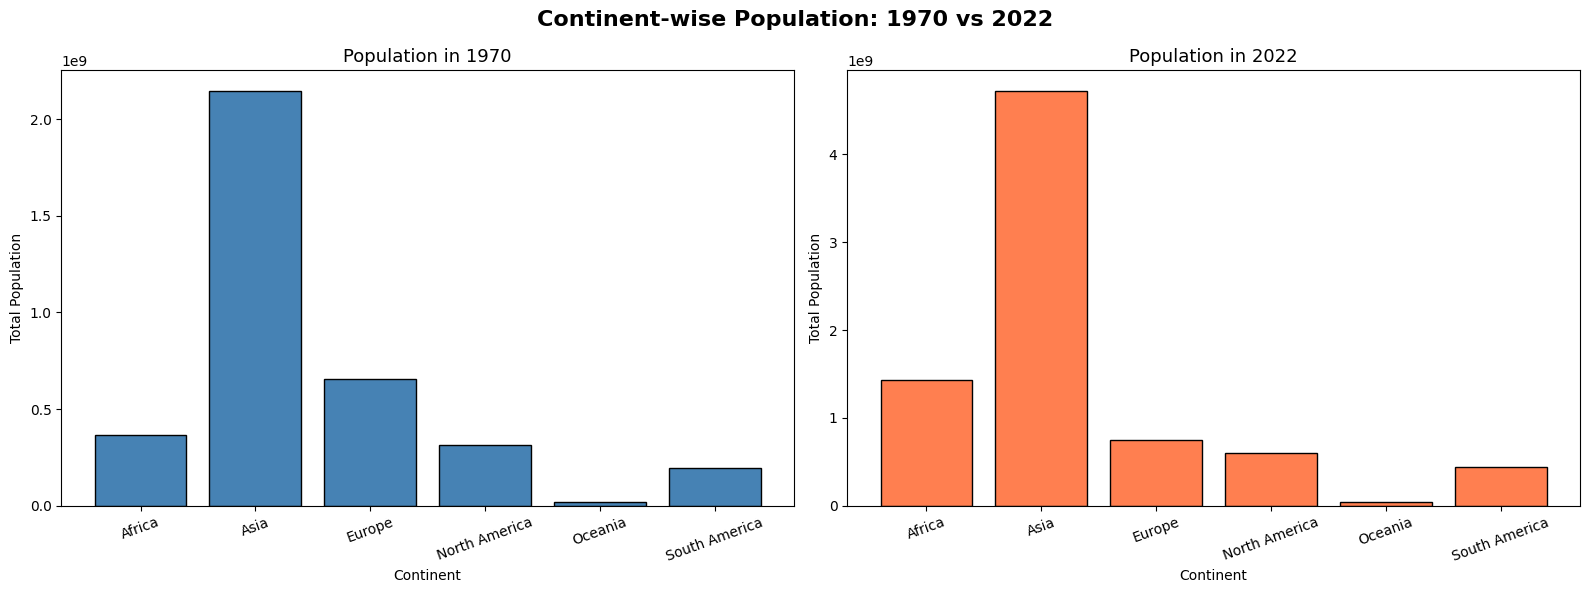

In [15]:
# Group total population by continent
pop_1970 = df.groupby("Continent")["1970"].sum()
pop_2022 = df.groupby("Continent")["2022"].sum()

continents = pop_1970.index.tolist()

# Create side by side charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Continent-wise Population: 1970 vs 2022",
             fontsize=16, fontweight="bold")

# 1970 bar chart
axes[0].bar(continents, pop_1970.values,
            color="steelblue", edgecolor="black")
axes[0].set_title("Population in 1970", fontsize=13)
axes[0].set_xlabel("Continent")
axes[0].set_ylabel("Total Population")
axes[0].tick_params(axis="x", rotation=20)

# 2022 bar chart
axes[1].bar(continents, pop_2022.values,
            color="coral", edgecolor="black")
axes[1].set_title("Population in 2022", fontsize=13)
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Total Population")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("population_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

**Step-15**

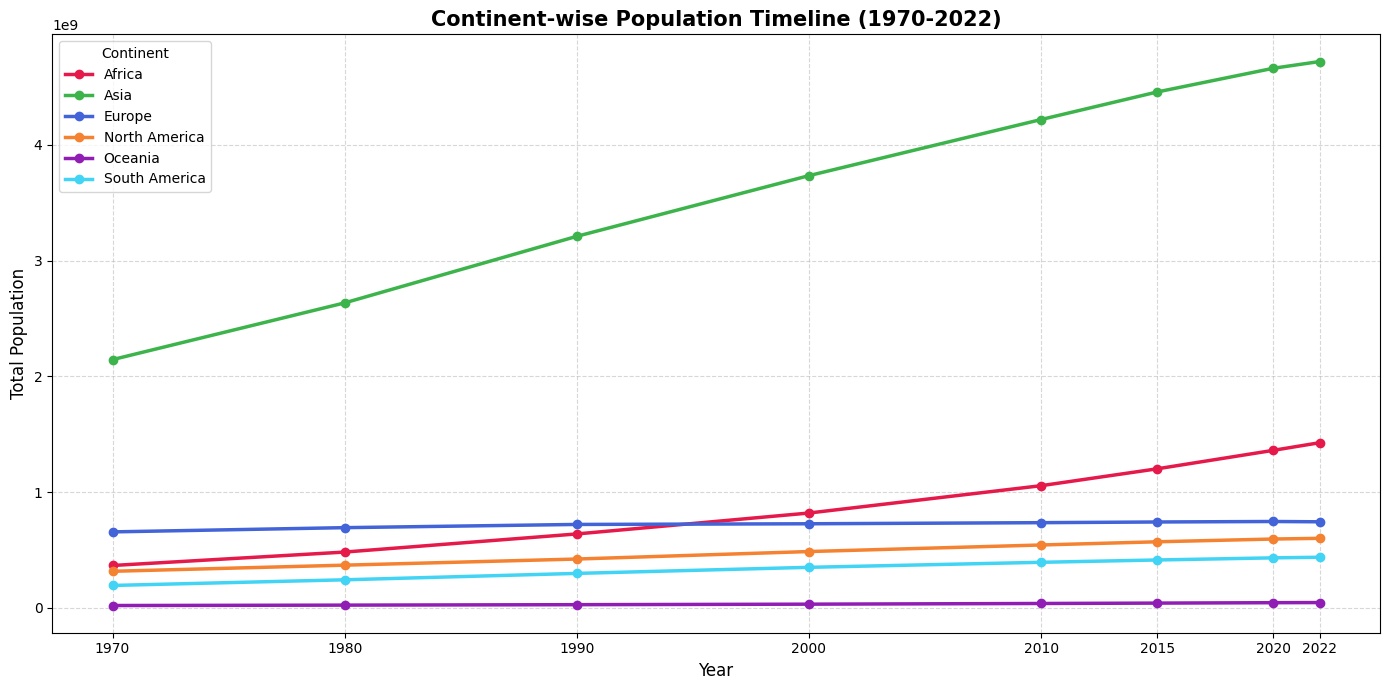

In [16]:
#step 15
# Year columns
year_cols = ['1970','1980','1990','2000','2010','2015','2020','2022']
years = [int(y) for y in year_cols]

# Group by continent - sum population per year
continent_timeline = df.groupby("Continent")[year_cols].sum()

# Plot timeline
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4']

for i, continent in enumerate(continent_timeline.index):
    ax.plot(years, continent_timeline.loc[continent].values,
            marker='o', linewidth=2.5,
            label=continent, color=colors[i])

ax.set_title("Continent-wise Population Timeline (1970-2022)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Population", fontsize=12)
ax.legend(title="Continent", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xticks(years)

plt.tight_layout()
plt.savefig("population_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

**Step-16**

                   1970  1980  1990  2000  2010  2015  2020  2022  Area (km²)  \
1970               1.00  1.00  1.00  0.99  0.98  0.98  0.98  0.97        0.51   
1980               1.00  1.00  1.00  1.00  0.99  0.99  0.98  0.98        0.50   
1990               1.00  1.00  1.00  1.00  0.99  0.99  0.99  0.99        0.49   
2000               0.99  1.00  1.00  1.00  1.00  1.00  1.00  0.99        0.47   
2010               0.98  0.99  0.99  1.00  1.00  1.00  1.00  1.00        0.46   
2015               0.98  0.99  0.99  1.00  1.00  1.00  1.00  1.00        0.46   
2020               0.98  0.98  0.99  1.00  1.00  1.00  1.00  1.00        0.45   
2022               0.97  0.98  0.99  0.99  1.00  1.00  1.00  1.00        0.45   
Area (km²)         0.51  0.50  0.49  0.47  0.46  0.46  0.45  0.45        1.00   
Density (per km²) -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03       -0.06   
Growth Rate       -0.08 -0.07 -0.06 -0.05 -0.04 -0.03 -0.03 -0.02       -0.01   
World Percentage   0.97  0.9

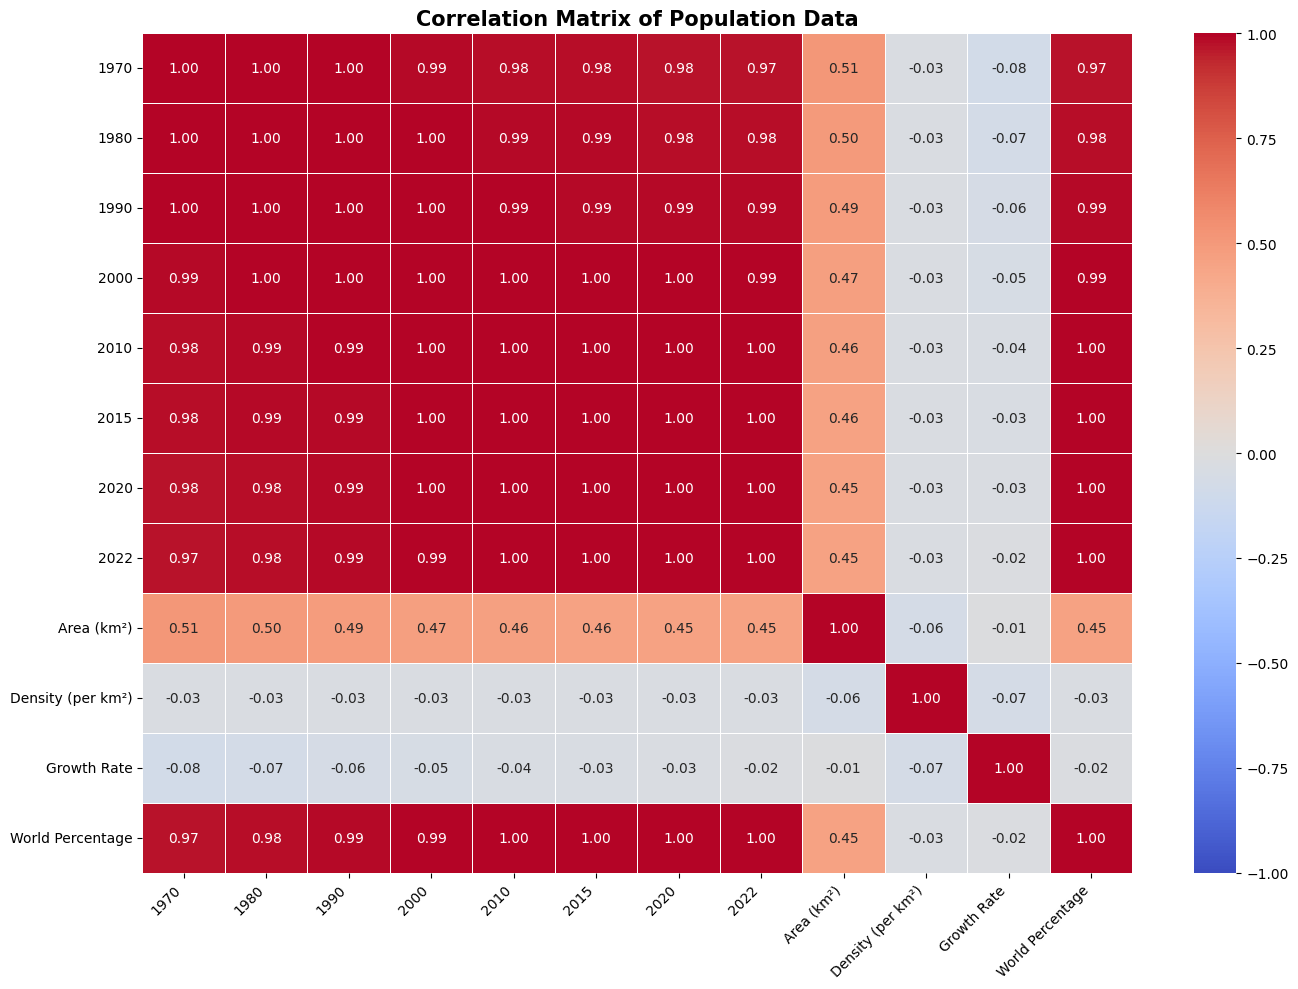


Statistical Analysis of Correlation Matrix:
------------------------------------------
1. Population Columns: All population columns (from 1970 to 2022) are highly positively correlated with each other. This is expected, as countries that had a large population in one year are likely to have a large population in subsequent years, reflecting continuous growth trends.
2. Area (km²) vs. Population: 'Area (km²)' generally shows a positive correlation with population figures, indicating that larger countries tend to have higher populations. However, this correlation is not extremely strong, suggesting other factors like population density are also significant.
3. Density (per km²): 'Density (per km²)' shows varying correlations. It has a weak positive correlation with population, indicating that while total population is high, it doesn't always translate to high density if the area is also very large. It has a negative correlation with 'Area (km²)', which is intuitive as larger areas tend

In [17]:
#step 16
import seaborn as sns
# Select only numerical columns
numerical_cols = ['1970','1980','1990','2000','2010','2015','2020','2022',
                  'Area (km²)', 'Density (per km²)',
                  'Growth Rate', 'World Percentage']

df_numeric = df[numerical_cols]

# Compute correlation matrix
corr_matrix = df_numeric.corr()
print(corr_matrix.round(2))

# Visualize as heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,       # show numbers inside boxes
    fmt='.2f',        # 2 decimal places
    cmap='coolwarm',  # blue = negative, red = positive
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Population Data',
          fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nStatistical Analysis of Correlation Matrix:")
print("------------------------------------------")
print("1. Population Columns: All population columns (from 1970 to 2022) are highly positively correlated with each other. This is expected, as countries that had a large population in one year are likely to have a large population in subsequent years, reflecting continuous growth trends.")
print("2. Area (km²) vs. Population: 'Area (km²)' generally shows a positive correlation with population figures, indicating that larger countries tend to have higher populations. However, this correlation is not extremely strong, suggesting other factors like population density are also significant.")
print("3. Density (per km²): 'Density (per km²)' shows varying correlations. It has a weak positive correlation with population, indicating that while total population is high, it doesn't always translate to high density if the area is also very large. It has a negative correlation with 'Area (km²)', which is intuitive as larger areas tend to dilute density for a given population.")
print("4. Growth Rate: 'Growth Rate' shows relatively low and mixed correlations with historical population figures and 'Area (km²)'. This suggests that population growth is influenced by more dynamic factors than just historical size or land area. It might be slightly negatively correlated with 'World Population Percentage' and recent population numbers, indicating that countries with very large populations might have stabilizing or slower growth rates compared to smaller, rapidly developing nations.")
print("5. World Population Percentage: This column is very highly correlated with the population columns, especially '2022' population. This is direct as 'World Population Percentage' is derived from a country's total population relative to the global total.")
print("6. Rank: 'Rank' (which is likely based on 2022 population) shows a strong negative correlation with population numbers and 'World Population Percentage'. This is because a lower rank number (e.g., Rank 1) corresponds to a higher population.")
print("\nOverall, the correlation matrix confirms intuitive relationships between population figures over time and their relationship with geographical factors and global share, while highlighting the independent nature of 'Growth Rate' from sheer size.")

